# MaPLe: Multi-modal Prompt Learning Experiments

This notebook runs MaPLe experiments from the CVPR 2023 setup.

Main differences from CoOp:
- Deep prompts are used across multiple transformer layers.
- Prompts are used in both text and vision encoders.
- Vision prompts are generated from text prompts through a learnable projection.

Experiments in this notebook:
1. Standard few-shot evaluation
2. Base-to-new generalization
3. Prompt-depth ablations


## 1. Setup and Configuration

Set paths, imports, and default experiment settings.


In [1]:
# Install dependencies if needed.
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install git+https://github.com/openai/CLIP.git
%pip install tqdm matplotlib seaborn pandas scikit-learn
%pip install ipywidgets widgetsnbextension jupyterlab_widgets

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-jwspplo3
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-jwspplo3
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json
import pickle
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import clip

# Set plotting style.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA RTX A4000


In [3]:
# Import MaPLe modules.
from maple_model import (
    CustomCLIPMaPLe, 
    MaPLePromptLearner,
    build_maple_model,
    compute_harmonic_mean,
    split_classes_base_new,
)
from maple_datasets import (
    build_maple_loader,
    build_base_new_loaders,
    get_base_new_split,
    get_all_dataset_names,
    DATASET_INFO,
)
from train_maple import (
    train_maple,
    evaluate,
    run_maple_experiment,
    get_epochs_for_shots,
)

print("MaPLe modules loaded successfully!")

MaPLe modules loaded successfully!


In [4]:
# Local path configuration.
# Update these paths for your local setup.

# Path to your datasets (containing caltech-101, oxford_pets, dtd, eurosat folders)
DATA_ROOT = "/scratch/HS400/AML_Dataset"

# Output directory for results, checkpoints, and plots.
OUTPUT_BASE = "/scratch/HS400/maple_results"  # Will be created in current directory

# Create output directories.
import os

OUTPUT_DIR = os.path.join(OUTPUT_BASE, "output")
PLOTS_DIR = os.path.join(OUTPUT_BASE, "plots")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
WEIGHTS_DIR = os.path.join(OUTPUT_DIR, "weights")
PROGRESS_FILE = os.path.join(OUTPUT_DIR, "experiment_progress.pkl")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print("=" * 60)
print("LOCAL GPU SETUP (A4000)")
print("=" * 60)
print(f"Data root:    {DATA_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")
print(f"Plots dir:    {PLOTS_DIR}")
print(f"Checkpoints:  {CHECKPOINTS_DIR}")
print(f"Weights:      {WEIGHTS_DIR}")
print(f"Progress:     {PROGRESS_FILE}")
print("=" * 60)

# Verify that DATA_ROOT exists.
if not os.path.isdir(DATA_ROOT):
    print(f"\n⚠️  WARNING: DATA_ROOT does not exist: {DATA_ROOT}")
    print("   Please update DATA_ROOT to point to your dataset directory.")
else:
    print(f"\n✓ DATA_ROOT exists")
    print(f"  Contents: {os.listdir(DATA_ROOT)[:10]}...")

# Path to CoOp results for comparison.
COOP_RESULTS_DIR = "/scratch/HS400/coop_results/output"

LOCAL GPU SETUP (A4000)
Data root:    /scratch/HS400/AML_Dataset
Output dir:   /scratch/HS400/maple_results/output
Plots dir:    /scratch/HS400/maple_results/plots
Checkpoints:  /scratch/HS400/maple_results/output/checkpoints
Weights:      /scratch/HS400/maple_results/output/weights
Progress:     /scratch/HS400/maple_results/output/experiment_progress.pkl

✓ DATA_ROOT exists
  Contents: ['fgvc_aircraft', 'oxford_flowers', 'food-101', 'caltech-101', 'stanford_cars', 'eurosat', 'oxford_pets', 'dtd', 'ucf101']...


In [5]:
# Experiment configuration (paper-aligned).
CONFIG = dict(
    # Dataset options.
    data_root=DATA_ROOT,  # Uses DATA_ROOT from paths cell above
    
    # MaPLe paper parameters.
    n_ctx=2,                    # M = 2 learnable context tokens (MaPLe paper default)
    prompt_depth=9,             # J = 9 layers for deep prompts (MaPLe paper default)
    ctx_init="",                # Empty = random initialization
    lr=0.0035,                  # Learning rate (MaPLe paper default, lower than CoOp's 0.002)
    
    # Training settings.
    batch_size=4,              # Batch size
    warmup_epochs=1,            # Warmup epochs
    warmup_lr=1e-5,             # Warmup learning rate
    
    # Epoch schedule from the paper.
    # Evaluate every 5 epochs.
    epochs_by_shots={1: 5, 4: 5, 8: 5, 16: 5},
    
    # Other settings.
    num_workers=2,
    eval_freq=1,
    
    # Model settings.
    clip_backbone="ViT-B/16",
)

# Sweep configuration.
SWEEP_CONFIG = dict(
    # Datasets to train on (your 4 target datasets - same as CoOp)
    datasets=["eurosat", "oxfordpets", "dtd", "caltech101", "flowers102", "fgvcaircraft", "stanfordcars", "ucf101", "food101"],
    
    # Shots: 1, 4, 8, 16 (same as CoOp)
    shots=[1, 4, 8, 16],
    
    # Single seed (same as CoOp)
    seeds=[1],
)

# Device selection.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
print(f"\nMaPLe Parameters:")
print(f"  Context tokens (n_ctx):  {CONFIG['n_ctx']}")
print(f"  Prompt depth (J):        {CONFIG['prompt_depth']}")
print(f"  Learning rate:           {CONFIG['lr']}")
print(f"  CLIP backbone:           {CONFIG['clip_backbone']}")

print(f"\nSweep Configuration:")
print(f"  Datasets: {SWEEP_CONFIG['datasets']}")
print(f"  Shots:    {SWEEP_CONFIG['shots']}")
print(f"  Seeds:    {SWEEP_CONFIG['seeds']}")

total_experiments = (
    len(SWEEP_CONFIG['datasets']) * 
    len(SWEEP_CONFIG['shots']) * 
    len(SWEEP_CONFIG['seeds'])
)
print(f"\nTotal experiments: {total_experiments}")
print(f"Device: {DEVICE}")

EXPERIMENT CONFIGURATION

MaPLe Parameters:
  Context tokens (n_ctx):  2
  Prompt depth (J):        9
  Learning rate:           0.0035
  CLIP backbone:           ViT-B/16

Sweep Configuration:
  Datasets: ['eurosat', 'oxfordpets', 'dtd', 'caltech101', 'flowers102', 'fgvcaircraft', 'stanfordcars', 'ucf101', 'food101']
  Shots:    [1, 4, 8, 16]
  Seeds:    [1]

Total experiments: 36
Device: cuda


In [6]:
# Set random seeds for reproducibility.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SWEEP_CONFIG['seeds'][0])
print("Random seeds set.")

Random seeds set.


In [7]:
# Load the CLIP model.
print(f"Loading CLIP model: {CONFIG['clip_backbone']}...")
clip_model, preprocess = clip.load(CONFIG['clip_backbone'], device=DEVICE)
clip_model.eval()

# Store the preprocess function in CONFIG.
CONFIG['preprocess'] = preprocess

print(f"CLIP model loaded: {CONFIG['clip_backbone']}")
print(f"  Vision encoder: {clip_model.visual.conv1.weight.shape[0]} dim")
print(f"  Text encoder: {clip_model.ln_final.weight.shape[0]} dim")

Loading CLIP model: ViT-B/16...
CLIP model loaded: ViT-B/16
  Vision encoder: 768 dim
  Text encoder: 512 dim


In [8]:
import os
import json

def generate_fgvc_json(data_dir):
    json_path = os.path.join(data_dir, "split_zhou_FGVCAircraft.json")
    
    # Parse the raw FGVC text files.
    splits = {
        "train": "images_variant_train.txt",
        "val": "images_variant_val.txt",
        "test": "images_variant_test.txt"
    }
    
    # 1. Collect and sort all unique class names to create a consistent label mapping (0 to 99)
    classes = set()
    for txt_file in splits.values():
        txt_path = os.path.join(data_dir, txt_file)
        if not os.path.exists(txt_path):
            print(f"Error: Could not find {txt_file} in {data_dir}. Make sure the dataset is extracted correctly!")
            return
            
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split(' ', 1)
                if len(parts) == 2:
                    classes.add(parts[1])
                    
    class_list = sorted(list(classes))
    class_to_idx = {c: i for i, c in enumerate(class_list)}
    
    # Build the JSON format expected by maple_datasets.py.
    output_data = {"train": [], "val": [], "test": []}
    
    for split_name, txt_file in splits.items():
        txt_path = os.path.join(data_dir, txt_file)
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split(' ', 1)
                if len(parts) == 2:
                    img_id = parts[0]
                    classname = parts[1]
                    
                    # FGVC aircraft images are saved as {img_id}.jpg
                    relpath = f"{img_id}.jpg"
                    label = class_to_idx[classname]
                    
                    output_data[split_name].append([relpath, label, classname])
                    
    # Save the file where maple_datasets.py looks for it.
    with open(json_path, 'w') as f:
        json.dump(output_data, f)
        
    print(f"SUCCESS! Created {json_path}")
    print(f"Found {len(class_list)} classes and {sum(len(v) for v in output_data.values())} total images.")

# Set this to your dataset directory.
data_dir = "/scratch/HS400/AML_Dataset/fgvc_aircraft"
generate_fgvc_json(data_dir)

SUCCESS! Created /scratch/HS400/AML_Dataset/fgvc_aircraft/split_zhou_FGVCAircraft.json
Found 100 classes and 10000 total images.


---
## 2. Zero-shot CLIP Baseline

Run a zero-shot baseline for reference.


In [9]:
@torch.no_grad()
def zero_shot_clip(dataset_name, clip_model, preprocess, device, data_root):
    """Evaluate zero-shot CLIP on a dataset."""
    # Load test data.
    test_loader, classnames, n_classes = build_maple_loader(
        dataset_name, data_root, "test", preprocess,
        batch_size=32, num_workers=CONFIG['num_workers']
    )
    
    # Create text features with a standard prompt.
    prompts = [f"a photo of a {c}." for c in classnames]
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    
    # Run evaluation.
    correct = 0
    total = 0
    
    for images, labels in tqdm(test_loader, desc=f"Zero-shot {dataset_name}"):
        images = images.to(device)
        labels = labels.to(device)
        
        image_features = clip_model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        preds = similarity.argmax(dim=-1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    accuracy = 100.0 * correct / total
    return accuracy, classnames, n_classes

In [10]:
import tqdm
import tqdm.notebook
import tqdm.auto

# Use the standard text progress bar in torchvision.
tqdm.notebook.tqdm = tqdm.std.tqdm
tqdm.auto.tqdm = tqdm.std.tqdm

# 2. Bind the progress-bar function so loops can call it.
from tqdm import tqdm 

print("tqdm successfully patched and callable!")

tqdm successfully patched and callable!


In [11]:
# Run zero-shot baselines for all datasets.
zero_shot_results = {}

print("\n" + "="*60)
print("Zero-shot CLIP Baseline")
print("="*60)

for dataset in SWEEP_CONFIG['datasets']:
    try:
        acc, classnames, n_classes = zero_shot_clip(
            dataset, clip_model, preprocess, DEVICE, DATA_ROOT
        )
        zero_shot_results[dataset] = {
            "accuracy": acc,
            "n_classes": n_classes,
        }
        print(f"  {dataset:15s}: {acc:.2f}% ({n_classes} classes)")
    except Exception as e:
        print(f"  {dataset:15s}: FAILED - {str(e)[:50]}")
        zero_shot_results[dataset] = {"accuracy": 0.0, "n_classes": 0}

# Save zero-shot results.
zs_df = pd.DataFrame([
    {"dataset": k, "zero_shot_acc": v["accuracy"], "n_classes": v["n_classes"]}
    for k, v in zero_shot_results.items()
])
zs_df.to_csv(f"{OUTPUT_DIR}/zero_shot_baseline.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR}/zero_shot_baseline.csv")


Zero-shot CLIP Baseline


Zero-shot eurosat: 100%|██████████████████████| 254/254 [00:21<00:00, 11.78it/s]


  eurosat        : 42.06% (10 classes)


Zero-shot oxfordpets: 100%|███████████████████| 115/115 [00:09<00:00, 11.84it/s]


  oxfordpets     : 87.30% (37 classes)


...

  stanfordcars   : 65.60% (196 classes)


Zero-shot ucf101: 100%|███████████████████████| 119/119 [00:10<00:00, 11.63it/s]


  ucf101         : 64.26% (101 classes)


Zero-shot food101: 100%|██████████████████████| 947/947 [01:20<00:00, 11.78it/s]

  food101        : 83.67% (101 classes)

Saved: /scratch/HS400/maple_results/output/zero_shot_baseline.csv


---
## 3. MaPLe Training Functions

Training and evaluation utilities.


In [17]:
def run_single_experiment(
    dataset_name,
    num_shots,
    seed,
    n_ctx=None,
    prompt_depth=None,
    epochs=None,
    lr=None,
    verbose=True
):
    """
    Run a single MaPLe experiment.
    
    Returns:
        dict with experiment results
    """
    # Use CONFIG defaults when values are not provided.
    n_ctx = n_ctx or CONFIG['n_ctx']
    prompt_depth = prompt_depth or CONFIG['prompt_depth']
    lr = lr or CONFIG['lr']
    
    set_seed(seed)
    
    # Choose epochs based on shot count.
    if epochs is None:
        epochs = CONFIG['epochs_by_shots'].get(num_shots, 100)
    
    exp_name = f"maple_{dataset_name}_ctx{n_ctx}_depth{prompt_depth}_shots{num_shots}_seed{seed}"
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_name}")
        print(f"{'='*60}")
    
    # Load data.
    train_loader, classnames, n_classes = build_maple_loader(
        dataset_name, DATA_ROOT, "train", preprocess,
        batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'],
        num_shots=num_shots, seed=seed
    )
    
    test_loader, _, _ = build_maple_loader(
        dataset_name, DATA_ROOT, "test", preprocess,
        batch_size=100, num_workers=CONFIG['num_workers']
    )
    
    if verbose:
        print(f"  Dataset: {dataset_name} ({n_classes} classes)")
        print(f"  Training samples: {len(train_loader.dataset)}")
        print(f"  Test samples: {len(test_loader.dataset)}")
    
    # Build the model.
    model = build_maple_model(
        classnames, clip_model,
        n_ctx=n_ctx, prompt_depth=prompt_depth
    )
    
    # Run the experiment.
    results = run_maple_experiment(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        config={
            "epochs": epochs, 
            "lr": lr, 
            "eval_freq": CONFIG['eval_freq'],
            "warmup_epochs": CONFIG['warmup_epochs'],
            "warmup_lr": CONFIG['warmup_lr'],
        },
        output_dir=OUTPUT_DIR,
        exp_name=exp_name,
        verbose=verbose
    )
    
    # Add metadata to the result.
    results.update({
        "dataset": dataset_name,
        "num_shots": num_shots,
        "seed": seed,
        "n_ctx": n_ctx,
        "prompt_depth": prompt_depth,
        "epochs": epochs,
        "lr": lr,
        "n_classes": n_classes,
    })
    
    return results

---
## 4. Standard Few-shot Experiments

Run MaPLe across datasets and shot counts.


In [13]:
# Experiment configurations.
EXPERIMENT_CONFIGS = []

for dataset in SWEEP_CONFIG['datasets']:
    for shots in SWEEP_CONFIG['shots']:
        for seed in SWEEP_CONFIG['seeds']:
            EXPERIMENT_CONFIGS.append({
                "dataset": dataset,
                "shots": shots,
                "seed": seed,
            })

print(f"Total experiments to run: {len(EXPERIMENT_CONFIGS)}")
print(f"  Datasets: {SWEEP_CONFIG['datasets']}")
print(f"  Shots: {SWEEP_CONFIG['shots']}")
print(f"  Seeds: {SWEEP_CONFIG['seeds']}")

Total experiments to run: 36
  Datasets: ['eurosat', 'oxfordpets', 'dtd', 'caltech101', 'flowers102', 'fgvcaircraft', 'stanfordcars', 'ucf101', 'food101']
  Shots: [1, 4, 8, 16]
  Seeds: [1]


In [14]:
# Progress tracking.
results_file = f"{OUTPUT_DIR}/all_results.csv"

# Load saved progress when available.
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, 'rb') as f:
        completed_experiments = pickle.load(f)
    print(f"Resuming from {len(completed_experiments)} completed experiments")
else:
    completed_experiments = set()

# Load saved results when available.
if os.path.exists(results_file):
    all_results_df = pd.read_csv(results_file)
    all_results = all_results_df.to_dict('records')
    print(f"Loaded {len(all_results)} existing results")
else:
    all_results = []

In [18]:
# Run experiments.
print("\n" + "="*70)
print("RUNNING MAPLE FEW-SHOT EXPERIMENTS")
print("="*70)

for i, config in enumerate(EXPERIMENT_CONFIGS):
    exp_key = f"{config['dataset']}_{config['shots']}shot_seed{config['seed']}"
    
    if exp_key in completed_experiments:
        print(f"[{i+1}/{len(EXPERIMENT_CONFIGS)}] SKIPPING (already done): {exp_key}")
        continue
    
    print(f"\n[{i+1}/{len(EXPERIMENT_CONFIGS)}] RUNNING: {exp_key}")
    
    try:
        results = run_single_experiment(
            dataset_name=config['dataset'],
            num_shots=config['shots'],
            seed=config['seed'],
            verbose=True
        )
        
        # Store the result.
        result_row = {
            "dataset": config['dataset'],
            "num_shots": config['shots'],
            "seed": config['seed'],
            "n_ctx": CONFIG['n_ctx'],
            "prompt_depth": CONFIG['prompt_depth'],
            "final_acc": results['final_acc'],
            "best_val_acc": results['best_val_acc'],
            "best_epoch": results['best_epoch'],
        }
        all_results.append(result_row)
        
        # Mark experiment as completed.
        completed_experiments.add(exp_key)
        
        # Save progress.
        with open(PROGRESS_FILE, 'wb') as f:
            pickle.dump(completed_experiments, f)
        
        # Save results.
        pd.DataFrame(all_results).to_csv(results_file, index=False)
        
        print(f"  ✓ Completed: {results['final_acc']:.2f}%")
        
    except Exception as e:
        print(f"  ✗ FAILED: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED")
print("="*70)


RUNNING MAPLE FEW-SHOT EXPERIMENTS
[1/36] SKIPPING (already done): eurosat_1shot_seed1

[2/36] RUNNING: eurosat_4shot_seed1

Experiment: maple_eurosat_ctx2_depth9_shots4_seed1
  Dataset: eurosat (10 classes)
  Training samples: 40
  Test samples: 8100
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization

Training: maple_eurosat_ctx2_depth9_shots4_seed1
Trainable parameters: 3,555,072 / 127,878,913
  (2.7800% of total)


Epoch 1/5: 100%|███████████████████| 10/10 [00:00<00:00, 19.09it/s, loss=1.8027]


  Epoch   1/5 | Train Loss: 1.6939 | Val Loss: 1.9102 | Val Acc: 30.62% | LR: 0.003500


Epoch 2/5: 100%|███████████████████| 10/10 [00:00<00:00, 18.76it/s, loss=2.0977]


  Epoch   2/5 | Train Loss: 1.8194 | Val Loss: 1.3218 | Val Acc: 55.44% | LR: 0.002987


...

  Epoch   3/5 | Train Loss: 0.3250 | Val Loss: 0.5330 | Val Acc: 84.88% | LR: 0.001750


Epoch 4/5: 100%|█████████████████| 404/404 [01:10<00:00,  5.72it/s, loss=0.0187]


  Epoch   4/5 | Train Loss: 0.2498 | Val Loss: 0.5099 | Val Acc: 85.90% | LR: 0.000513


Epoch 5/5: 100%|█████████████████| 404/404 [01:10<00:00,  5.71it/s, loss=0.0231]


  Epoch   5/5 | Train Loss: 0.1726 | Val Loss: 0.4997 | Val Acc: 86.47% | LR: 0.000000

  Final Test Accuracy: 86.47%
  Best Val Accuracy: 87.42% (epoch 2)
  ✓ Completed: 86.47%

ALL EXPERIMENTS COMPLETED


---
## 5. Base-to-New Generalization Experiments

Train on base classes and evaluate on unseen classes.


In [19]:
def run_base_to_new_experiment(
    dataset_name,
    num_shots=16,
    seed=1,
    n_ctx=None,
    prompt_depth=None,
    epochs=None,
    lr=None,
    verbose=True
):
    """
    Run base-to-new generalization experiment.
    
    - Train on BASE classes only
    - Evaluate on both BASE and NEW classes
    - Report: Base Acc, New Acc, Harmonic Mean
    """
    # Use CONFIG defaults when values are not provided.
    n_ctx = n_ctx or CONFIG['n_ctx']
    prompt_depth = prompt_depth or CONFIG['prompt_depth']
    lr = lr or CONFIG['lr']
    
    set_seed(seed)
    
    if epochs is None:
        epochs = CONFIG['epochs_by_shots'].get(num_shots, 100)
    
    exp_name = f"maple_b2n_{dataset_name}_shots{num_shots}_seed{seed}"
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Base-to-New Experiment: {exp_name}")
        print(f"{'='*60}")
    
    # Build loaders with a base/new split.
    loaders = build_base_new_loaders(
        dataset_name, DATA_ROOT, preprocess,
        batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'],
        num_shots=num_shots, seed=seed
    )
    
    train_loader = loaders['train_loader']
    base_test_loader = loaders['base_test_loader']
    new_test_loader = loaders['new_test_loader']
    base_classes = loaders['base_classes']
    new_classes = loaders['new_classes']
    
    if verbose:
        print(f"  Base classes: {len(base_classes)}")
        print(f"  New classes: {len(new_classes)}")
        print(f"  Training samples: {len(train_loader.dataset)}")
    
    # Build a model for base classes only.
    model = build_maple_model(
        base_classes, clip_model,
        n_ctx=n_ctx, prompt_depth=prompt_depth
    )
    
    # Train on base classes.
    history = train_maple(
        model=model,
        train_loader=train_loader,
        val_loader=base_test_loader,
        device=DEVICE,
        epochs=epochs,
        lr=lr,
        eval_freq=CONFIG['eval_freq'],
        verbose=verbose
    )
    
    # Evaluate on base classes.
    base_acc = evaluate(model, base_test_loader, DEVICE)
    
    # For new classes, rebuild the model with new class names.
    # Reuse the learned prompts.
    model_new = build_maple_model(
        new_classes, clip_model,
        n_ctx=n_ctx, prompt_depth=prompt_depth
    )
    
    # Copy learned prompts to the new model.
    # Copy only context vectors, not class-specific suffix tokens.
    with torch.no_grad():
        model_new.prompt_learner.ctx.copy_(model.prompt_learner.ctx)
        if model.prompt_learner.deep_text_prompts is not None:
            for i, param in enumerate(model.prompt_learner.deep_text_prompts):
                model_new.prompt_learner.deep_text_prompts[i].copy_(param)
        for i, coupler in enumerate(model.prompt_learner.vl_couplers):
            model_new.prompt_learner.vl_couplers[i].load_state_dict(coupler.state_dict())
    
    model_new = model_new.to(DEVICE)
    new_acc = evaluate(model_new, new_test_loader, DEVICE)
    
    # Compute the harmonic mean.
    h_mean = compute_harmonic_mean(base_acc, new_acc)
    
    if verbose:
        print(f"\n  Results:")
        print(f"    Base Accuracy: {base_acc:.2f}%")
        print(f"    New Accuracy:  {new_acc:.2f}%")
        print(f"    Harmonic Mean: {h_mean:.2f}%")
    
    # Save model weights.
    weights_path = f"{WEIGHTS_DIR}/{exp_name}_weights.pt"
    torch.save(model.prompt_learner.state_dict(), weights_path)
    
    # Save training history.
    history_path = f"{OUTPUT_DIR}/history_{exp_name}.json"
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    
    return {
        "dataset": dataset_name,
        "num_shots": num_shots,
        "seed": seed,
        "base_acc": base_acc,
        "new_acc": new_acc,
        "h_mean": h_mean,
        "n_base_classes": len(base_classes),
        "n_new_classes": len(new_classes),
        "weights_path": weights_path,
        "history_path": history_path,
    }

In [20]:
# Run base-to-new experiments.
base_to_new_results = []

print("\n" + "="*70)
print("RUNNING BASE-TO-NEW GENERALIZATION EXPERIMENTS")
print("="*70)

for dataset in SWEEP_CONFIG['datasets']:
    for seed in SWEEP_CONFIG['seeds']:
        try:
            results = run_base_to_new_experiment(
                dataset_name=dataset,
                num_shots=16,
                seed=seed,
                verbose=True
            )
            base_to_new_results.append(results)
        except Exception as e:
            print(f"FAILED: {dataset} seed={seed}: {str(e)}")
            import traceback
            traceback.print_exc()

# Save base-to-new results.
b2n_df = pd.DataFrame(base_to_new_results)
b2n_df.to_csv(f"{OUTPUT_DIR}/base_to_new_results.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR}/base_to_new_results.csv")


RUNNING BASE-TO-NEW GENERALIZATION EXPERIMENTS

Base-to-New Experiment: maple_b2n_eurosat_shots16_seed1
  Base classes: 5
  New classes: 5
  Training samples: 80
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization
Trainable parameters: 3,555,072 / 127,878,913
  (2.7800% of total)


Epoch 1/5: 100%|███████████████████| 20/20 [00:00<00:00, 21.16it/s, loss=0.3254]


  Epoch   1/5 | Train Loss: 0.7325 | Val Loss: 0.5427 | Val Acc: 79.54% | LR: 0.003500


Epoch 2/5: 100%|███████████████████| 20/20 [00:00<00:00, 21.56it/s, loss=0.4573]


  Epoch   2/5 | Train Loss: 0.3678 | Val Loss: 0.3336 | Val Acc: 87.21% | LR: 0.002987


...

  Epoch   3/5 | Train Loss: 0.2101 | Val Loss: 0.3106 | Val Acc: 91.08% | LR: 0.001750


Epoch 4/5: 100%|█████████████████| 200/200 [00:21<00:00,  9.45it/s, loss=0.0763]


  Epoch   4/5 | Train Loss: 0.1373 | Val Loss: 0.3053 | Val Acc: 91.37% | LR: 0.000513


Epoch 5/5: 100%|█████████████████| 200/200 [00:21<00:00,  9.45it/s, loss=0.0408]


  Epoch   5/5 | Train Loss: 0.0761 | Val Loss: 0.3273 | Val Acc: 90.83% | LR: 0.000000
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization

  Results:
    Base Accuracy: 90.83%
    New Accuracy:  89.31%
    Harmonic Mean: 90.06%

Saved: /scratch/HS400/maple_results/output/base_to_new_results.csv


---
## 6. Results Analysis and Visualization


In [21]:
# Load all result files.
results_df = pd.read_csv(f"{OUTPUT_DIR}/all_results.csv")
print(f"Loaded {len(results_df)} experiment results")
results_df.head(10)

Loaded 36 experiment results


,dataset,num_shots,seed,n_ctx,prompt_depth,final_acc,best_val_acc,best_epoch
0,eurosat,1,1,2,9,57.666667,58.703704,3
1,eurosat,4,1,2,9,79.567901,79.567901,5
2,eurosat,8,1,2,9,84.864198,84.864198,5
3,eurosat,16,1,2,9,89.654321,89.654321,5
4,oxfordpets,1,1,2,9,91.278277,91.278277,5
5,oxfordpets,4,1,2,9,93.431453,93.485963,3
6,oxfordpets,8,1,2,9,93.049877,93.049877,4
7,oxfordpets,16,1,2,9,94.031071,94.031071,5
8,dtd,1,1,2,9,52.127660,52.364066,2
9,dtd,4,1,2,9,60.933806,60.933806,5


In [22]:
# Summarize statistics by dataset and shot count.
summary = results_df.groupby(['dataset', 'num_shots']).agg({
    'final_acc': ['mean'],
    'best_val_acc': ['mean'],
}).round(2)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv(f"{OUTPUT_DIR}/summary_by_dataset_shots.csv", index=False)
print("Summary by dataset and shots:")
summary

Summary by dataset and shots:


,dataset,num_shots,final_acc_mean,best_val_acc_mean
0,caltech101,1,93.43,93.47
1,caltech101,4,94.93,94.93
2,caltech101,8,95.01,95.21
3,caltech101,16,95.86,95.86
4,dtd,1,52.13,52.36
5,dtd,4,60.93,60.93
6,dtd,8,65.13,65.13
7,dtd,16,68.97,68.97
8,eurosat,1,57.67,58.70
9,eurosat,4,79.57,79.57


### 6.1 Few-shot Accuracy vs Number of Shots


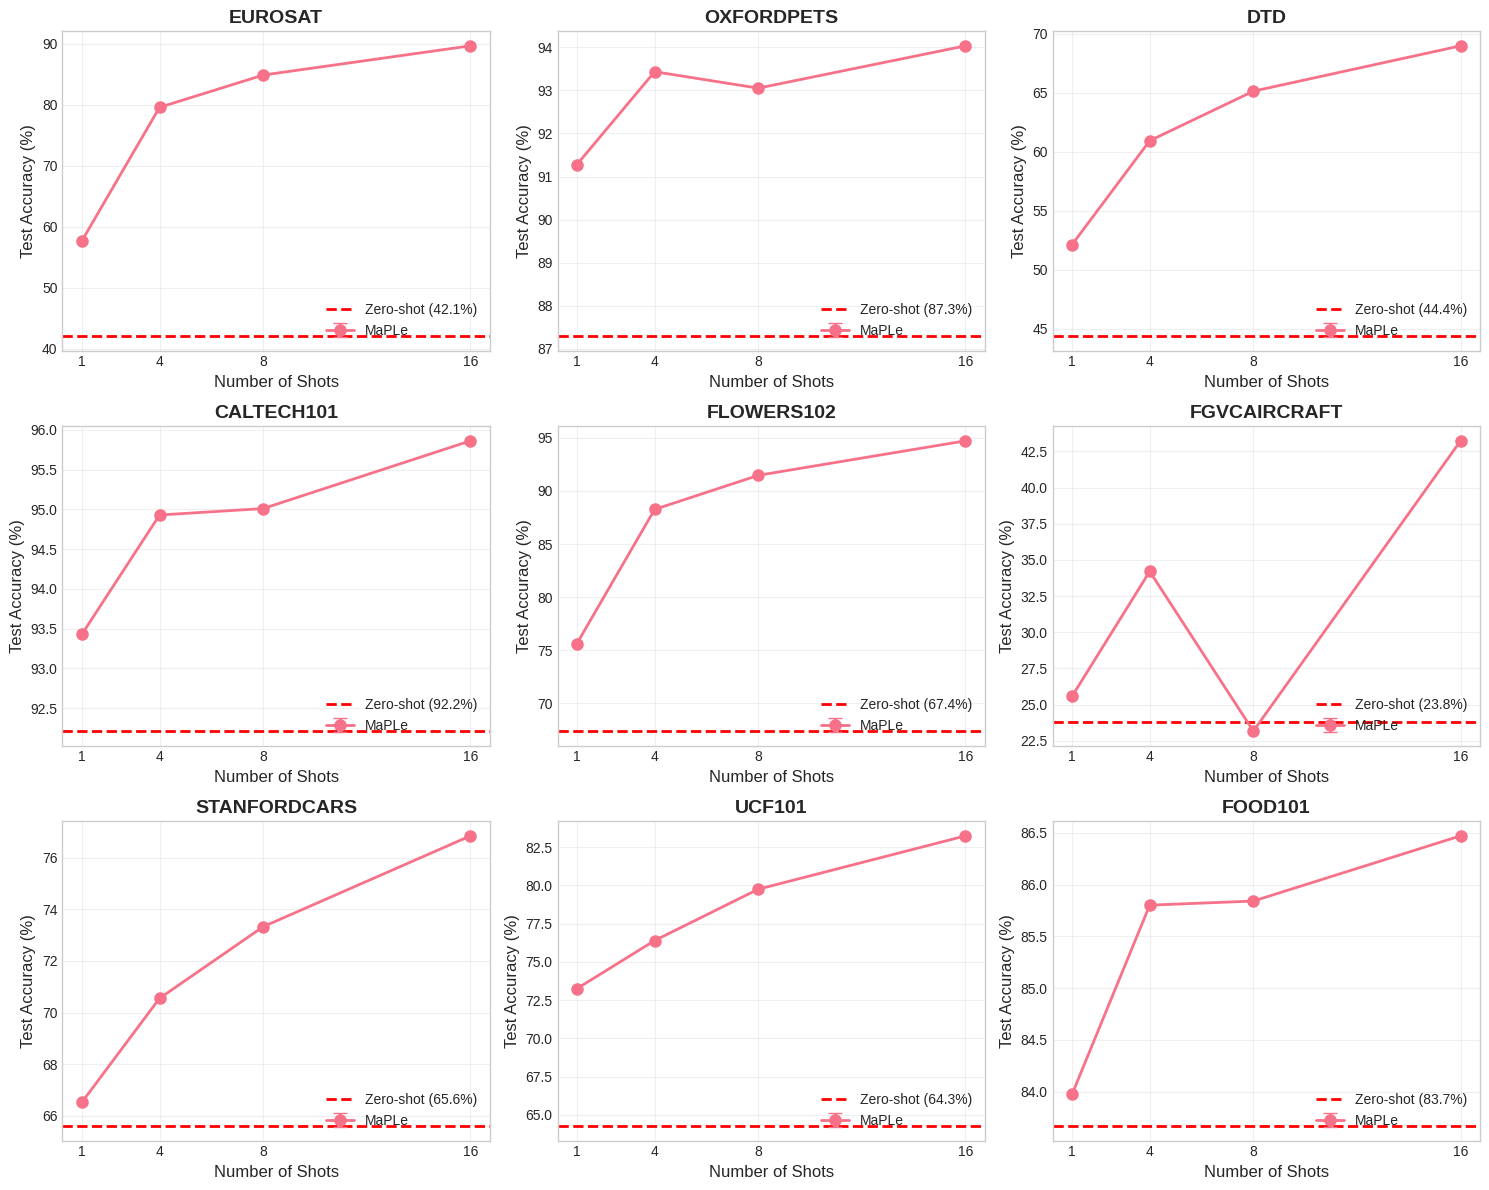

Saved: /scratch/HS400/maple_results/plots/shots_comparison.png


In [23]:
# Plot: Accuracy vs Shots for each dataset
import math
import matplotlib.pyplot as plt

# Calculate subplot grid size from dataset count.
num_datasets = len(SWEEP_CONFIG['datasets'])
cols = 3 # Let's do 3 columns for a nice wide layout
rows = math.ceil(num_datasets / cols)

# Create subplots.
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() # Flatten to a 1D array so we can index it easily

for idx, dataset in enumerate(SWEEP_CONFIG['datasets']):
    ax = axes[idx]
    data = results_df[results_df['dataset'] == dataset]
    
    # Group results by shots.
    grouped = data.groupby('num_shots')['final_acc'].agg(['mean', 'std']).reset_index()
    
    # Plot with error bars.
    ax.errorbar(
        grouped['num_shots'], grouped['mean'], yerr=grouped['std'],
        marker='o', markersize=8, capsize=5, linewidth=2, label='MaPLe'
    )
    
    # Add the zero-shot baseline.
    if dataset in zero_shot_results:
        zs_acc = zero_shot_results[dataset]['accuracy']
        ax.axhline(y=zs_acc, color='red', linestyle='--', linewidth=2, label=f'Zero-shot ({zs_acc:.1f}%)')
    
    ax.set_xlabel('Number of Shots', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title(f'{dataset.upper()}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(SWEEP_CONFIG['shots'])

for idx in range(num_datasets, len(axes)):
    fig.delaxes(axes[idx])
    
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/shots_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/shots_comparison.png")

### 6.2 Performance Heatmap


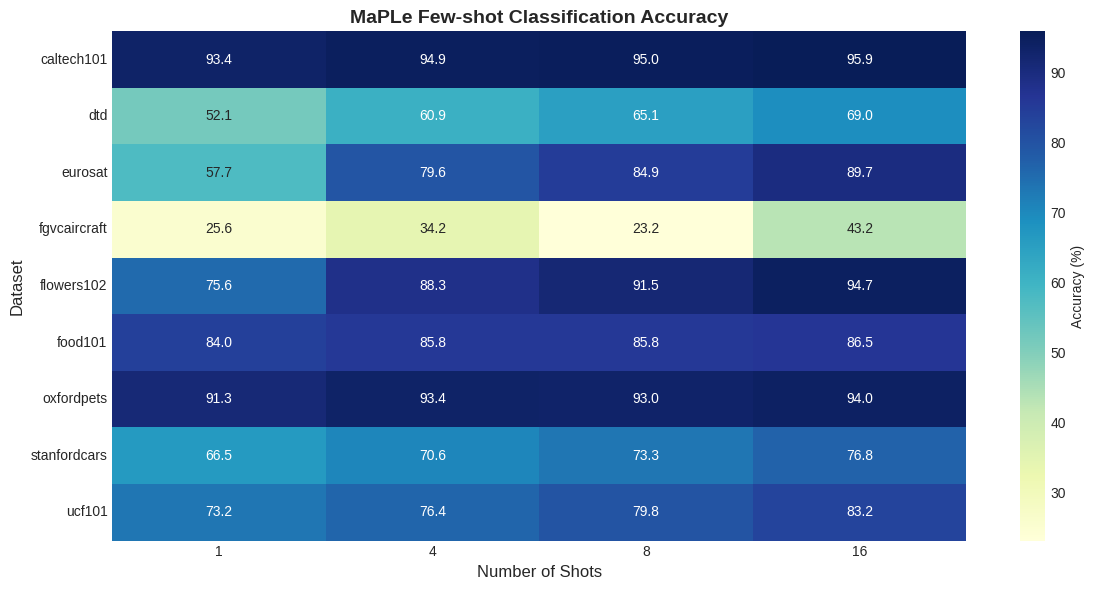

Saved: /scratch/HS400/maple_results/plots/performance_heatmap.png


In [24]:
# Create an accuracy heatmap.
pivot = results_df.groupby(['dataset', 'num_shots'])['final_acc'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlGnBu',
    cbar_kws={'label': 'Accuracy (%)'}
)
plt.title('MaPLe Few-shot Classification Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Number of Shots', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/performance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/performance_heatmap.png")

### 6.3 Base-to-New Generalization Results


In [25]:
# Load and display base-to-new results.
if os.path.exists(f"{OUTPUT_DIR}/base_to_new_results.csv"):
    b2n_df = pd.read_csv(f"{OUTPUT_DIR}/base_to_new_results.csv")
    
    # Summary.
    b2n_summary = b2n_df.groupby('dataset').agg({
        'base_acc': ['mean'],
        'new_acc': ['mean'],
        'h_mean': ['mean'],
    }).round(2)
    b2n_summary.columns = ['_'.join(col) for col in b2n_summary.columns]
    
    print("Base-to-New Generalization Summary:")
    print(b2n_summary)
    
    b2n_summary.to_csv(f"{OUTPUT_DIR}/base_to_new_summary.csv")
else:
    print("Base-to-new results not found. Run the experiments first.")

Base-to-New Generalization Summary:
              base_acc_mean  new_acc_mean  h_mean_mean
dataset                                               
caltech101            97.89         92.79        95.28
dtd                   82.73         48.84        61.42
eurosat               94.54         68.69        79.57
fgvcaircraft          47.99         18.02        26.20
flowers102            96.70         79.15        87.05
food101               90.83         89.31        90.06
oxfordpets            94.62         91.45        93.01
stanfordcars          83.24         73.18        77.89
ucf101                85.78         84.26        85.02


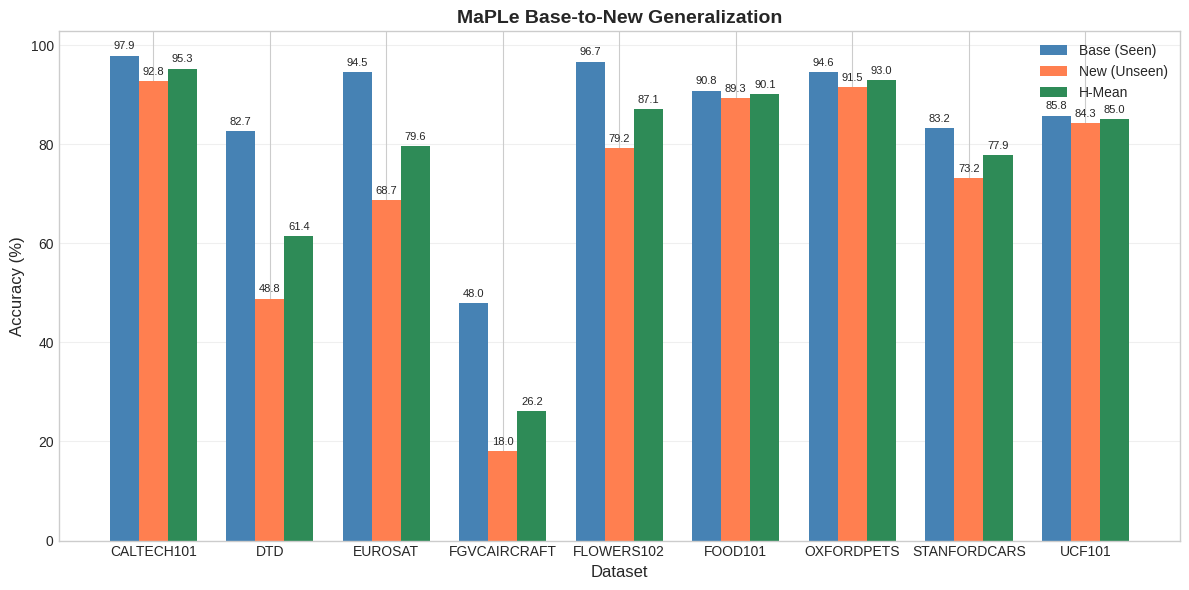

Saved: /scratch/HS400/maple_results/plots/base_to_new_comparison.png


In [26]:
# Plot: Base vs New accuracy
if os.path.exists(f"{OUTPUT_DIR}/base_to_new_results.csv"):
    b2n_df = pd.read_csv(f"{OUTPUT_DIR}/base_to_new_results.csv")
    
    # Draw a grouped bar chart.
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data.
    b2n_mean = b2n_df.groupby('dataset')[['base_acc', 'new_acc', 'h_mean']].mean().reset_index()
    b2n_std = b2n_df.groupby('dataset')[['base_acc', 'new_acc', 'h_mean']].std().reset_index()
    
    x = np.arange(len(b2n_mean))
    width = 0.25
    
    bars1 = ax.bar(x - width, b2n_mean['base_acc'], width, yerr=b2n_std['base_acc'],
                   label='Base (Seen)', capsize=3, color='steelblue')
    bars2 = ax.bar(x, b2n_mean['new_acc'], width, yerr=b2n_std['new_acc'],
                   label='New (Unseen)', capsize=3, color='coral')
    bars3 = ax.bar(x + width, b2n_mean['h_mean'], width, yerr=b2n_std['h_mean'],
                   label='H-Mean', capsize=3, color='seagreen')
    
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('MaPLe Base-to-New Generalization', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([d.upper() for d in b2n_mean['dataset']])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels.
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/base_to_new_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PLOTS_DIR}/base_to_new_comparison.png")

### 6.4 Training Curves


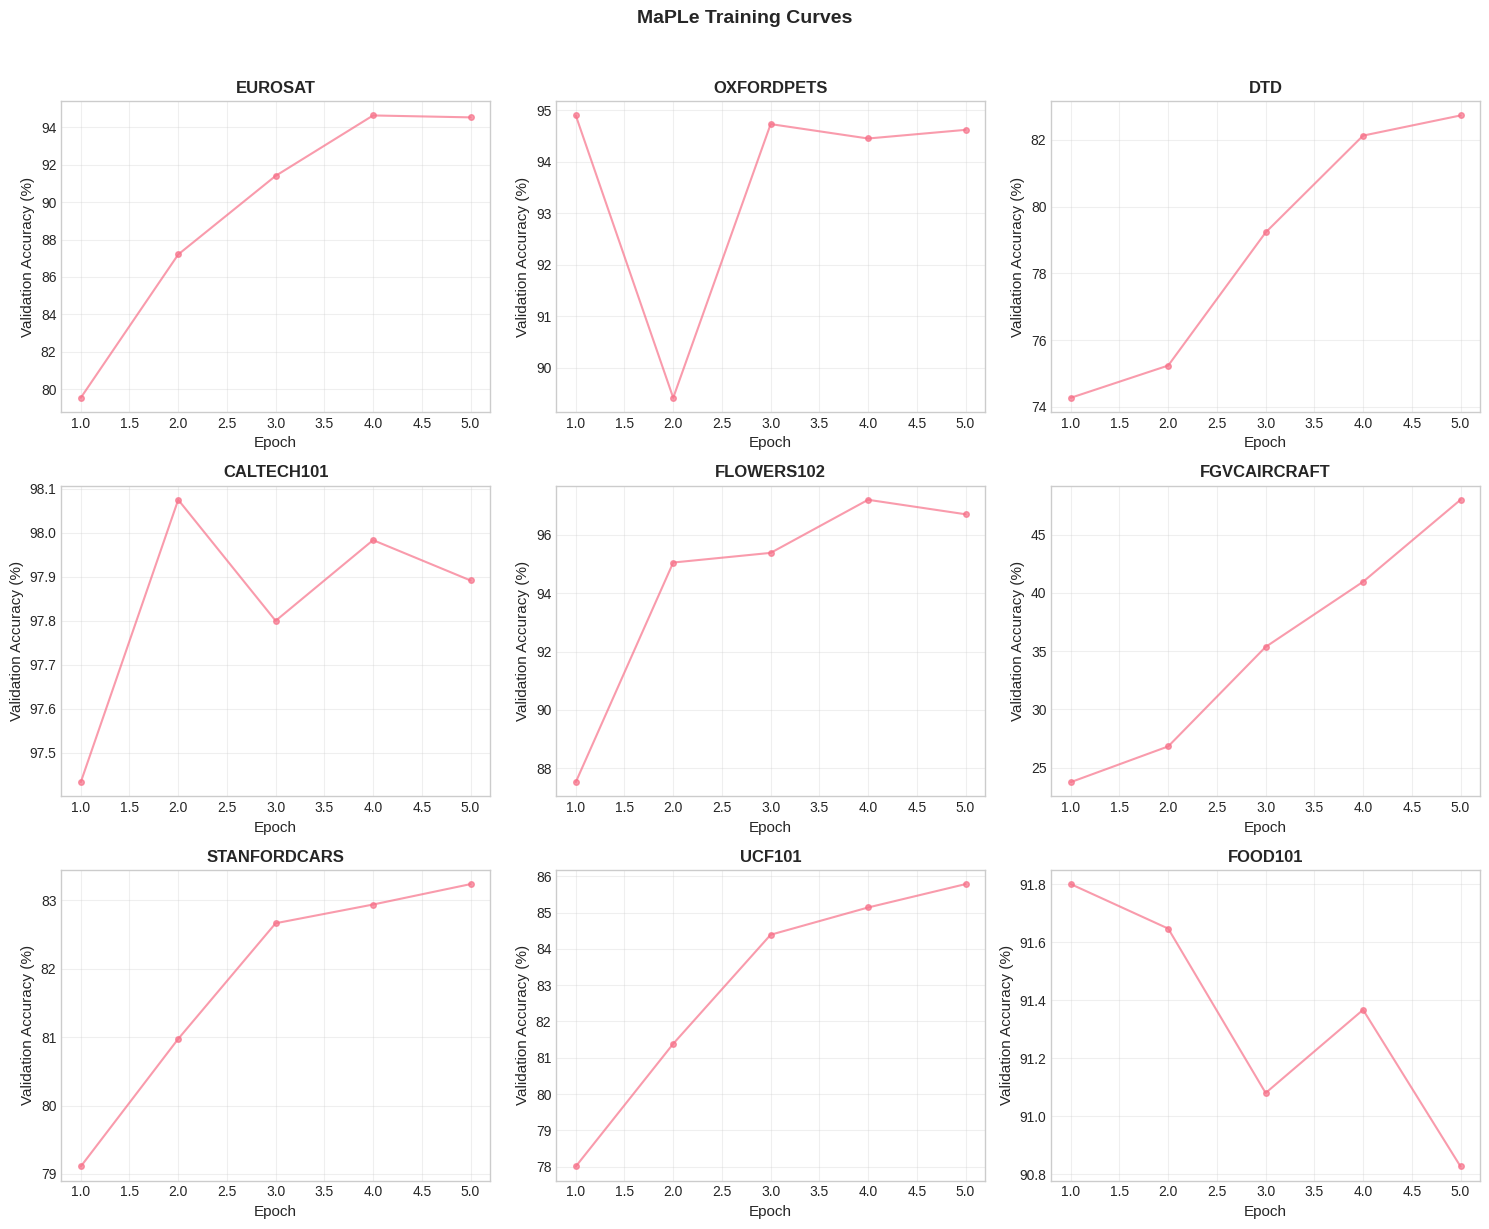

Saved: /scratch/HS400/maple_results/plots/training_curves.png


In [27]:
import glob
import math
import os
import json
import matplotlib.pyplot as plt

history_files = glob.glob(f"{OUTPUT_DIR}/history_*.json")

if history_files:
    # Calculate subplot grid size from dataset count.
    num_datasets = len(SWEEP_CONFIG['datasets'])
    cols = 3  # 3 columns looks good for 6 datasets
    rows = math.ceil(num_datasets / cols)
    
    # Create subplots with dynamic sizing.
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    for idx, dataset in enumerate(SWEEP_CONFIG['datasets']):
        ax = axes[idx]
        
        # Find history files for this dataset.
        dataset_files = [f for f in history_files if dataset in f]
        
        for hist_file in dataset_files[:3]:  # Limit to 3 for clarity
            with open(hist_file, 'r') as f:
                history = json.load(f)
            
            label = os.path.basename(hist_file).replace('history_maple_', '').replace('.json', '')
            ax.plot(history['epoch'], history['val_acc'], marker='o', markersize=4, alpha=0.7, label=label)
        
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
        ax.set_title(f'{dataset.upper()}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        # Optional: uncomment the line below if you want to see a legend on each plot
        # ax.legend(fontsize=8)
    
    # Hide unused subplots when the grid has extra slots.
    for idx in range(num_datasets, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('MaPLe Training Curves', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save and display the figure.
    plt.savefig(f"{PLOTS_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PLOTS_DIR}/training_curves.png")
else:
    print("No history files found.")

---
## 7. Comparison with CoOp

Compare MaPLe results with CoOp baselines.


In [28]:
# Load CoOp results when available.
coop_results_path = f"{COOP_RESULTS_DIR}/all_results.csv"

if os.path.exists(coop_results_path):
    coop_df = pd.read_csv(coop_results_path)
    print(f"Loaded {len(coop_df)} CoOp results")
    
    # Rename columns for consistency when needed.
    if 'test_acc' in coop_df.columns:
        coop_df = coop_df.rename(columns={'test_acc': 'final_acc'})
    if 'shots' in coop_df.columns:
        coop_df = coop_df.rename(columns={'shots': 'num_shots'})
    
    coop_df['method'] = 'CoOp'
else:
    print(f"CoOp results not found at: {coop_results_path}")
    coop_df = None

Loaded 144 CoOp results


In [29]:
# Combine result tables.
maple_df = results_df.copy()
maple_df['method'] = 'MaPLe'

if coop_df is not None:
    # Find common columns.
    common_cols = ['dataset', 'num_shots', 'seed', 'final_acc', 'method']
    available_cols = [c for c in common_cols if c in maple_df.columns and c in coop_df.columns]
    
    combined_df = pd.concat([maple_df[available_cols], coop_df[available_cols]], ignore_index=True)
    print(f"Combined dataset: {len(combined_df)} experiments")
else:
    combined_df = maple_df
    print("Using only MaPLe results (CoOp data not available)")

Combined dataset: 180 experiments


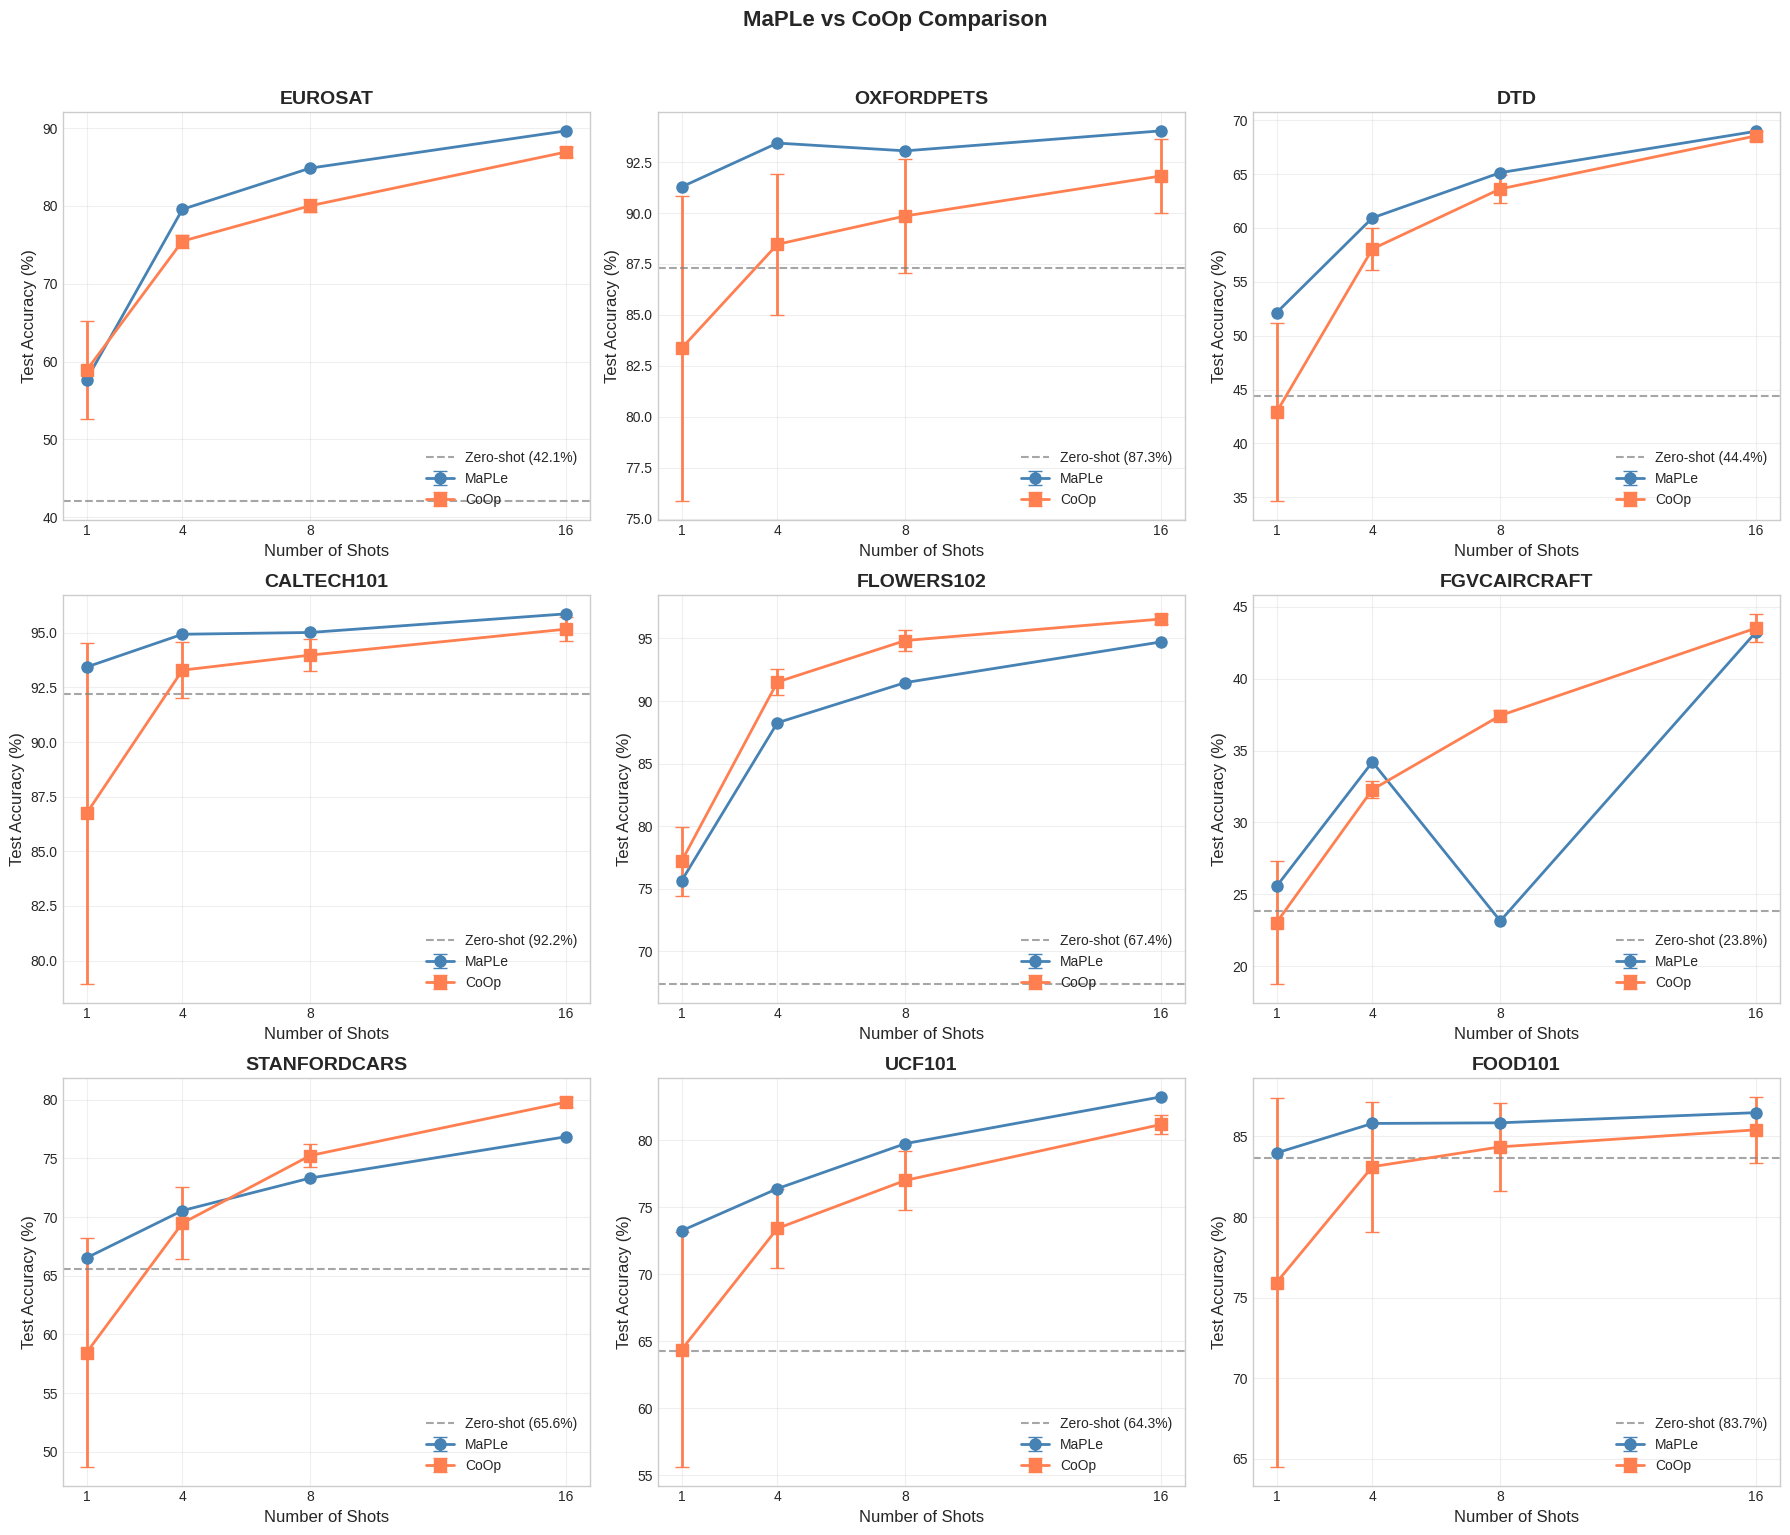

Saved: /scratch/HS400/maple_results/plots/maple_vs_coop_comparison.png


In [32]:
import math
import matplotlib.pyplot as plt

# Plot: MaPLe vs CoOp comparison
if coop_df is not None:
    
    # Standardize CoOp dataset names to match MaPLe.
    name_mapping = {
        'fgvc_aircraft': 'fgvcaircraft',
        'stanford_cars': 'stanfordcars',
        'oxfordflowers': 'flowers102',
        'oxford_flowers': 'flowers102' # Just in case it has an underscore
    }
    
    # Apply name mapping to the dataset column.
    combined_df['dataset'] = combined_df['dataset'].replace(name_mapping)

    # Calculate subplot grid size.
    num_datasets = len(SWEEP_CONFIG['datasets'])
    cols = 3  # Use 3 columns for a nice wide layout
    rows = math.ceil(num_datasets / cols)
    
    # Create subplots.
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()
    
    for idx, dataset in enumerate(SWEEP_CONFIG['datasets']):
        ax = axes[idx]
        
        for method, color, marker in [('MaPLe', 'steelblue', 'o'), ('CoOp', 'coral', 's')]:
            data = combined_df[(combined_df['dataset'] == dataset) & (combined_df['method'] == method)]
            if len(data) > 0:
                grouped = data.groupby('num_shots')['final_acc'].agg(['mean', 'std']).reset_index()
                ax.errorbar(
                    grouped['num_shots'], grouped['mean'], yerr=grouped['std'],
                    marker=marker, markersize=8, capsize=5, linewidth=2,
                    label=method, color=color
                )
        
        # Add the zero-shot baseline.
        if dataset in zero_shot_results:
            zs_acc = zero_shot_results[dataset]['accuracy']
            ax.axhline(y=zs_acc, color='gray', linestyle='--', linewidth=1.5,
                       label=f'Zero-shot ({zs_acc:.1f}%)', alpha=0.7)
        
        ax.set_xlabel('Number of Shots', fontsize=12)
        ax.set_ylabel('Test Accuracy (%)', fontsize=12)
        ax.set_title(f'{dataset.upper()}', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(SWEEP_CONFIG['shots'])
    
    # Hide unused subplots so empty panels do not appear.
    for idx in range(num_datasets, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('MaPLe vs CoOp Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/maple_vs_coop_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PLOTS_DIR}/maple_vs_coop_comparison.png")
else:
    print("Skipping comparison plot - CoOp results not available")

In [33]:
# Build an improvement table.
if coop_df is not None:
    # Calculate mean accuracy by method, dataset, and shots.
    comparison = combined_df.groupby(['method', 'dataset', 'num_shots'])['final_acc'].mean().unstack(level=0)
    
    if 'MaPLe' in comparison.columns and 'CoOp' in comparison.columns:
        comparison['Improvement'] = comparison['MaPLe'] - comparison['CoOp']
        comparison = comparison.round(2)
        
        print("\nMaPLe vs CoOp Improvement:")
        print(comparison)
        
        comparison.to_csv(f"{OUTPUT_DIR}/maple_vs_coop_comparison.csv")
        print(f"\nSaved: {OUTPUT_DIR}/maple_vs_coop_comparison.csv")


MaPLe vs CoOp Improvement:
method                   CoOp  MaPLe  Improvement
dataset      num_shots                           
caltech101   1          86.73  93.43         6.69
             4          93.29  94.93         1.64
             8          93.98  95.01         1.03
             16         95.16  95.86         0.70
dtd          1          42.89  52.13         9.23
             4          58.05  60.93         2.88
             8          63.62  65.13         1.51
             16         68.54  68.97         0.43
eurosat      1          58.86  57.67        -1.19
             4          75.48  79.57         4.09
             8          80.03  84.86         4.84
             16         86.94  89.65         2.72
fgvcaircraft 1          23.05  25.56         2.51
             4          32.29  34.20         1.91
             8          37.43  23.16       -14.27
             16         43.50  43.23        -0.27
flowers102   1          77.19  75.64        -1.55
             4        

### 7.1 Aggregated Bar Chart Comparison


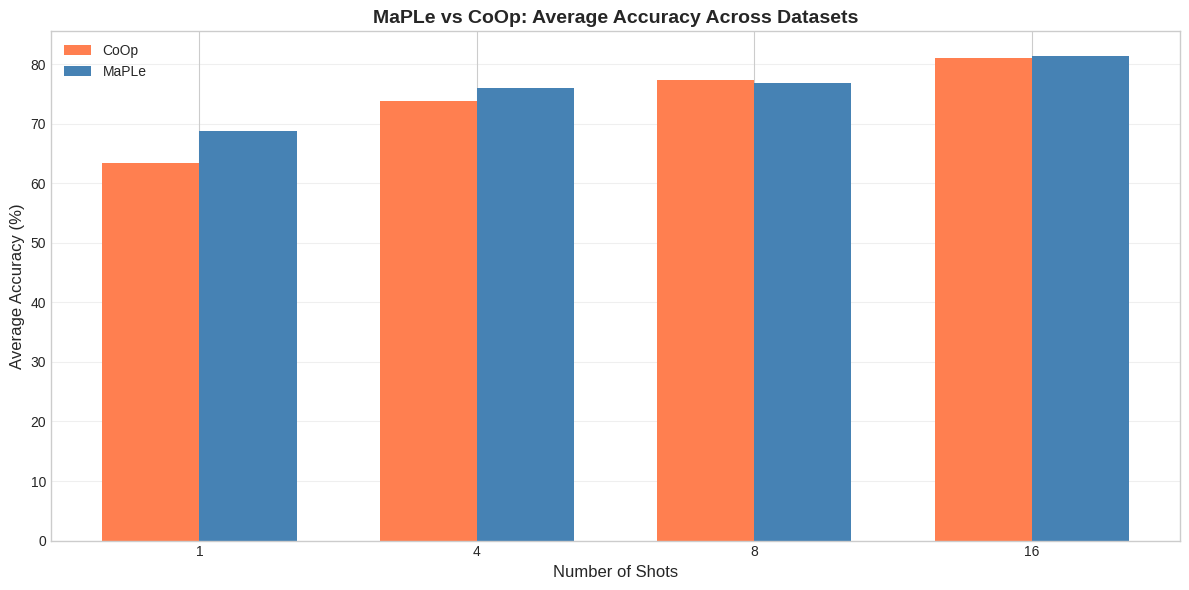

Saved: /scratch/HS400/maple_results/plots/aggregated_bar_chart.png


In [34]:
# Aggregate comparison across datasets.
if coop_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get mean accuracy per method and shot count.
    agg = combined_df.groupby(['method', 'num_shots'])['final_acc'].mean().unstack(level=0)
    
    x = np.arange(len(agg))
    width = 0.35
    
    if 'CoOp' in agg.columns:
        ax.bar(x - width/2, agg['CoOp'], width, label='CoOp', color='coral')
    if 'MaPLe' in agg.columns:
        ax.bar(x + width/2, agg['MaPLe'], width, label='MaPLe', color='steelblue')
    
    ax.set_xlabel('Number of Shots', fontsize=12)
    ax.set_ylabel('Average Accuracy (%)', fontsize=12)
    ax.set_title('MaPLe vs CoOp: Average Accuracy Across Datasets', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(agg.index)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/aggregated_bar_chart.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PLOTS_DIR}/aggregated_bar_chart.png")

---
## 8. Ablation Studies


In [35]:
# Ablation: Effect of prompt depth
def run_depth_ablation(dataset, depths=[1, 3, 6, 9, 12], shots=16, seed=1):
    """Run ablation on prompt depth."""
    results = []
    
    for depth in depths:
        print(f"\nTesting depth={depth}...")
        try:
            res = run_single_experiment(
                dataset_name=dataset,
                num_shots=shots,
                seed=seed,
                n_ctx=CONFIG['n_ctx'],
                prompt_depth=depth,
                lr=CONFIG['lr'],
                verbose=False
            )
            results.append({
                'depth': depth,
                'accuracy': res['final_acc']
            })
            print(f"  Depth {depth}: {res['final_acc']:.2f}%")
        except Exception as e:
            print(f"  Depth {depth}: FAILED - {str(e)}")
    
    return pd.DataFrame(results)


Testing depth=1...
MaPLe Config: n_ctx=2, prompt_depth=1
  Text dim: 512, Vision dim: 768
  Random initialization
  Depth 1: 75.31%

Testing depth=3...
MaPLe Config: n_ctx=2, prompt_depth=3
  Text dim: 512, Vision dim: 768
  Random initialization
  Depth 3: 89.09%

Testing depth=6...
MaPLe Config: n_ctx=2, prompt_depth=6
  Text dim: 512, Vision dim: 768
  Random initialization
  Depth 6: 89.86%

Testing depth=9...
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization
  Depth 9: 89.65%


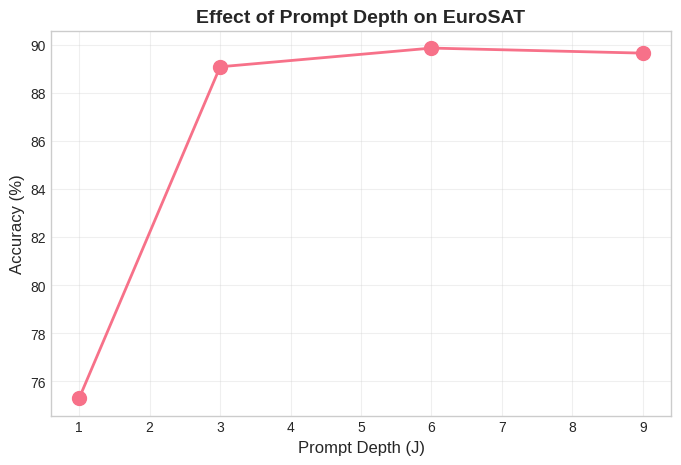

In [36]:
# Run depth ablation (uncomment to run - takes time)
depth_ablation_df = run_depth_ablation('eurosat', depths=[1, 3, 6, 9], shots=16, seed=1)
if len(depth_ablation_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(depth_ablation_df['depth'], depth_ablation_df['accuracy'], 'o-', linewidth=2, markersize=10)
    plt.xlabel('Prompt Depth (J)', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title('Effect of Prompt Depth on EuroSAT', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{PLOTS_DIR}/depth_ablation.png", dpi=150)
    plt.show()

---
## 9. Final Summary


In [37]:
# Generate a final summary report.
print("\n" + "="*70)
print("MAPLE EXPERIMENTS - FINAL SUMMARY")
print("="*70)

# Few-shot results summary.
if os.path.exists(f"{OUTPUT_DIR}/all_results.csv"):
    results_df = pd.read_csv(f"{OUTPUT_DIR}/all_results.csv")
    
    print("\n1. FEW-SHOT CLASSIFICATION RESULTS")
    print("-" * 50)
    
    for dataset in results_df['dataset'].unique():
        data = results_df[results_df['dataset'] == dataset]
        print(f"\n  {dataset.upper()}:")
        for shots in sorted(data['num_shots'].unique()):
            shot_data = data[data['num_shots'] == shots]
            mean_acc = shot_data['final_acc'].mean()
            std_acc = shot_data['final_acc'].std() if len(shot_data) > 1 else 0
            print(f"    {shots:2d}-shot: {mean_acc:.2f}%")

# Base-to-new results summary.
if os.path.exists(f"{OUTPUT_DIR}/base_to_new_results.csv"):
    b2n_df = pd.read_csv(f"{OUTPUT_DIR}/base_to_new_results.csv")
    
    print("\n\n2. BASE-TO-NEW GENERALIZATION RESULTS")
    print("-" * 50)
    
    for dataset in b2n_df['dataset'].unique():
        data = b2n_df[b2n_df['dataset'] == dataset]
        print(f"\n  {dataset.upper()}:")
        print(f"    Base Acc: {data['base_acc'].mean():.2f}%")
        print(f"    New Acc:  {data['new_acc'].mean():.2f}%")
        print(f"    H-Mean:   {data['h_mean'].mean():.2f}%")

print("\n\n3. OUTPUT FILES")
print("-" * 50)
print(f"  Results CSV: {OUTPUT_DIR}/all_results.csv")
print(f"  B2N Results: {OUTPUT_DIR}/base_to_new_results.csv")
print(f"  Plots: {PLOTS_DIR}/")
print(f"  Weights: {WEIGHTS_DIR}/")

print("\n" + "="*70)
print("EXPERIMENTS COMPLETE")
print("="*70)


MAPLE EXPERIMENTS - FINAL SUMMARY

1. FEW-SHOT CLASSIFICATION RESULTS
--------------------------------------------------

  EUROSAT:
     1-shot: 57.67%
     4-shot: 79.57%
     8-shot: 84.86%
    16-shot: 89.65%

  OXFORDPETS:
     1-shot: 91.28%
     4-shot: 93.43%
     8-shot: 93.05%
    16-shot: 94.03%

  DTD:
     1-shot: 52.13%
     4-shot: 60.93%
     8-shot: 65.13%
    16-shot: 68.97%

  CALTECH101:
     1-shot: 93.43%
     4-shot: 94.93%
     8-shot: 95.01%
    16-shot: 95.86%

  FLOWERS102:
     1-shot: 75.64%
     4-shot: 88.27%
     8-shot: 91.47%
    16-shot: 94.72%

  FGVCAIRCRAFT:
     1-shot: 25.56%
     4-shot: 34.20%
     8-shot: 23.16%
    16-shot: 43.23%

  STANFORDCARS:
     1-shot: 66.52%
     4-shot: 70.55%
     8-shot: 73.32%
    16-shot: 76.84%

  UCF101:
     1-shot: 73.25%
     4-shot: 76.39%
     8-shot: 79.75%
    16-shot: 83.24%

  FOOD101:
     1-shot: 83.97%
     4-shot: 85.80%
     8-shot: 85.84%
    16-shot: 86.47%


2. BASE-TO-NEW GENERALIZATION RESU

Setting up for visualization...
Loaded 10 classes from EuroSAT.
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization
Successfully loaded trained weights!
Extracting features for TSNE...
Filtered down to 8100 samples for targets.
Running TSNE reduction...
Saved: ./outputs/eurosat/plots/tsne_multi_class_visualization.png


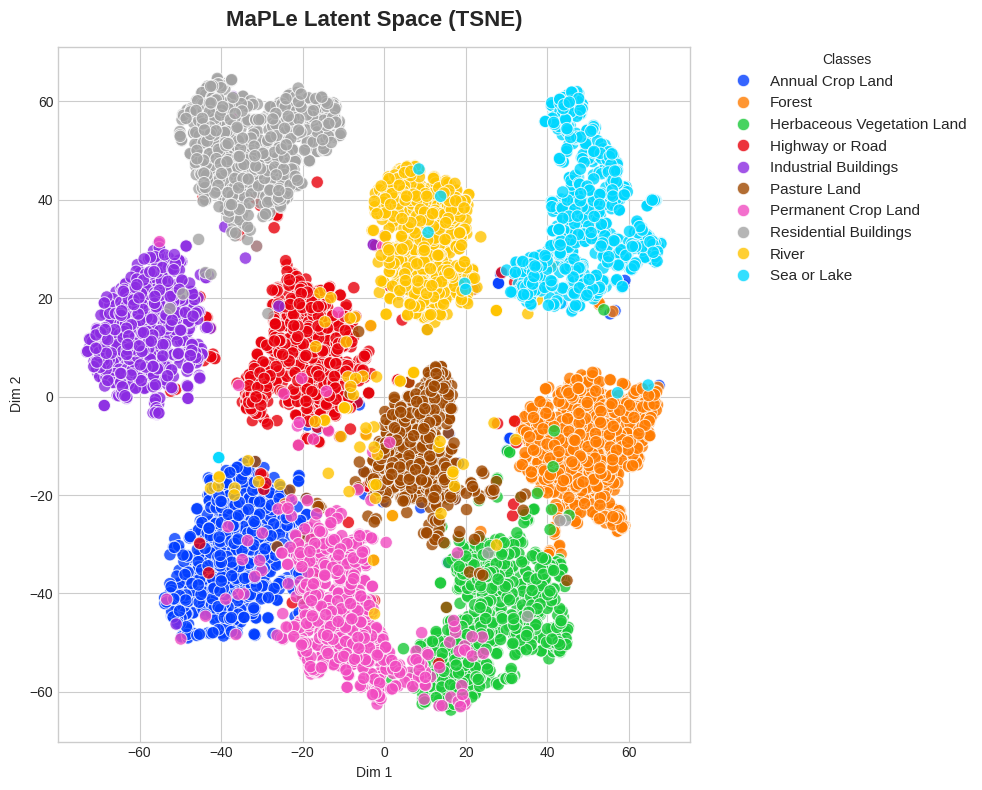

Extracting features for PCA...
Filtered down to 8100 samples for targets.
Running PCA reduction...
Saved: ./outputs/eurosat/plots/pca_multi_class_visualization.png


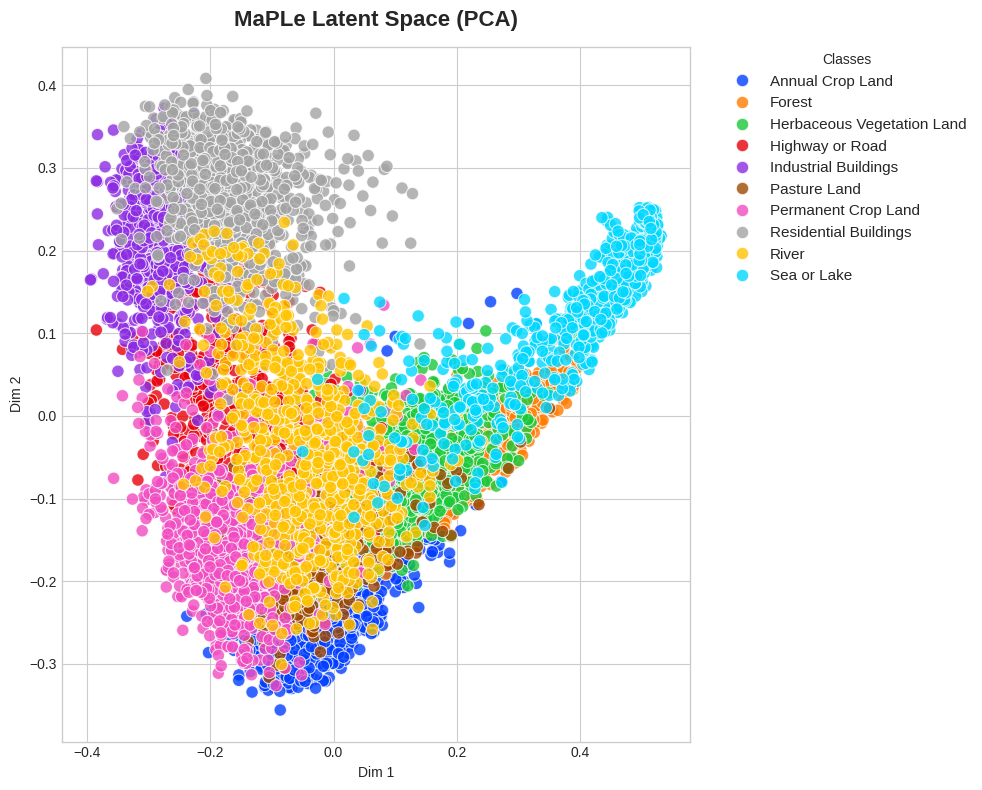

Extracting features for UMAP...
Filtered down to 8100 samples for targets.
Running UMAP reduction...


/scratch/HS400/VEnvs/MyEnv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: ./outputs/eurosat/plots/umap_multi_class_visualization.png


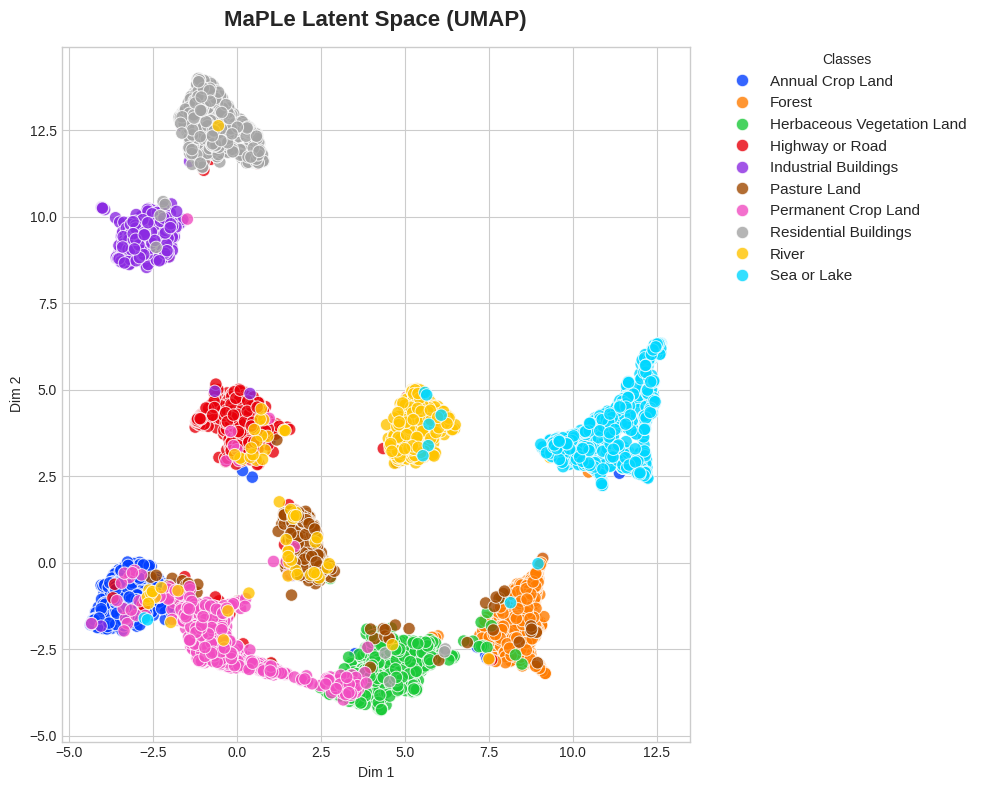

In [42]:
import os
import torch
import clip
from maple_model import build_maple_model
from maple_datasets import build_maple_loader

# Define device and paths.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "/scratch/HS400/AML_Dataset"
PLOTS_DIR = "./outputs/eurosat/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Setting up for visualization...")

# Load the CLIP backbone.
clip_model, preprocess = clip.load("ViT-B/16", device=DEVICE)

# 3. Build the Test Loader (This defines `test_loader` and `classnames`)
# Batch size is large here (128) because we are only evaluating, not training
test_loader, classnames, n_classes = build_maple_loader(
    dataset_name="eurosat", 
    data_root=DATA_ROOT, 
    split="test", 
    preprocess=preprocess,
    batch_size=128,  
    num_workers=2
)
print(f"Loaded {n_classes} classes from EuroSAT.")

# 4. Build the MaPLe Model (This defines `model`)
model = build_maple_model(
    classnames=classnames,
    clip_model=clip_model, 
    n_ctx=2, 
    prompt_depth=9
)
model = model.to(DEVICE)

# Load trained weights.
# Without this step, plots use a randomly initialized model.
weights_path = "/scratch/HS400/maple_results/output/weights/maple_eurosat_ctx2_depth9_shots16_seed1_weights.pt" 
if os.path.exists(weights_path):
    model.prompt_learner.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    print("Successfully loaded trained weights!")
else:
    print(f"WARNING: Could not find weights at {weights_path}. Plotting untrained features.")

# Now the plotting call can run safely.
# Plot all available classes instead of a subset.
plot_manifold(model, test_loader, classnames, target_classes=classnames, method='tsne')
plot_manifold(model, test_loader, classnames, target_classes=classnames, method='pca')
if HAS_UMAP:
    plot_manifold(model, test_loader, classnames, target_classes=classnames, method='umap')

---
## 10. Radar Chart Comparison


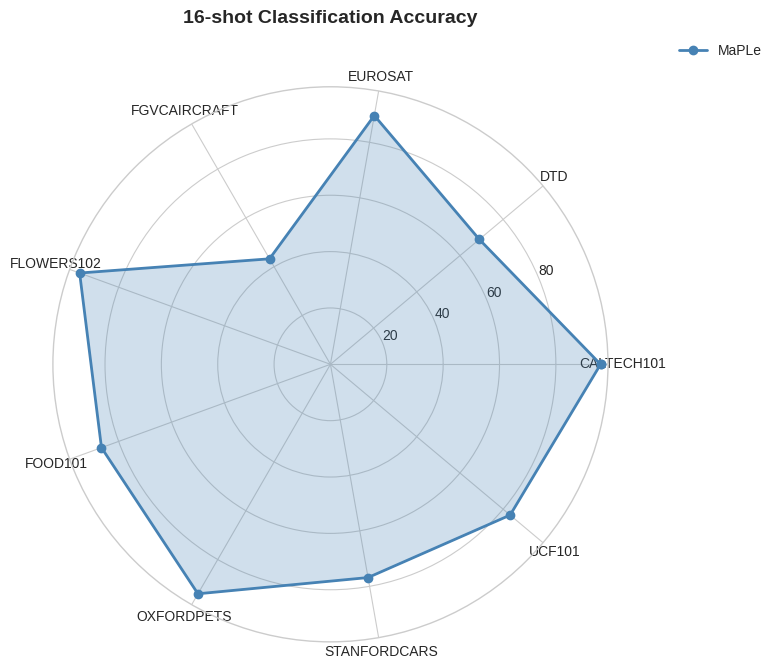

Saved: ./outputs/eurosat/plots/radar_chart.png


In [43]:
# Radar chart comparing methods across datasets.
from math import pi

def plot_radar_comparison(results_df, shots=16, methods=['MaPLe']):
    """Create radar chart comparing methods."""
    
    # Use 16-shot results.
    data = results_df[results_df['num_shots'] == shots]
    
    # Compute mean accuracy by dataset and method.
    if 'method' not in data.columns:
        data = data.copy()
        data['method'] = 'MaPLe'
    
    pivot = data.groupby(['dataset', 'method'])['final_acc'].mean().unstack()
    
    # Set up the radar chart.
    categories = list(pivot.index)
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    colors = ['steelblue', 'coral', 'seagreen']
    
    for idx, method in enumerate(pivot.columns):
        values = pivot[method].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=method, color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.25, color=colors[idx % len(colors)])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.upper() for d in categories], fontsize=10)
    ax.set_title(f'{shots}-shot Classification Accuracy', fontsize=14, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/radar_chart.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PLOTS_DIR}/radar_chart.png")

# Plot the radar chart.
if os.path.exists(f"{OUTPUT_DIR}/all_results.csv"):
    results_df = pd.read_csv(f"{OUTPUT_DIR}/all_results.csv")
    plot_radar_comparison(results_df, shots=16)

Generating Spider Map from CSV Results...


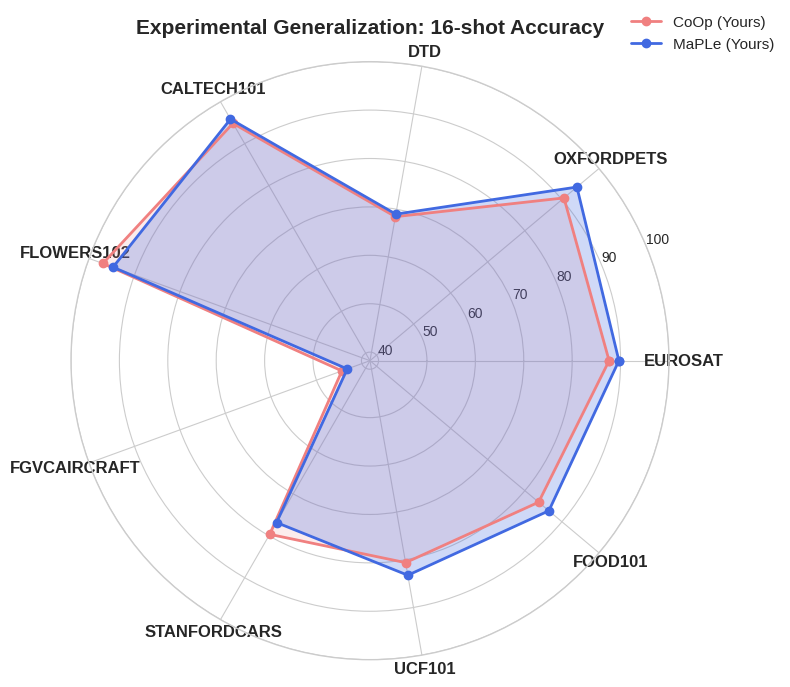

Saved: ./outputs/eurosat/plots/radar_maple_vs_coop_dynamic.png


In [46]:
# SPIDER MAP: Dynamically Loaded MaPLe vs CoOp
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
import os

def plot_dynamic_radar_comparison(maple_csv_path, coop_csv_path, shots=16):
    print("Generating Spider Map from CSV Results...")
    
    # Load result dataframes.
    if not os.path.exists(maple_csv_path):
        print(f"ERROR: Could not find MaPLe CSV at {maple_csv_path}")
        return
    if not os.path.exists(coop_csv_path):
        print(f"ERROR: Could not find CoOp CSV at {coop_csv_path}")
        return
        
    maple_df = pd.read_csv(maple_csv_path)
    coop_df = pd.read_csv(coop_csv_path)
    
    # Standardize CoOp dataset names to match MaPLe.
    name_mapping = {
        'fgvc_aircraft': 'fgvcaircraft',
        'stanford_cars': 'stanfordcars',
        'oxfordflowers': 'flowers102',
        'oxford_flowers': 'flowers102' # Just in case it has an underscore
    }
    
    # Apply dataset-name mapping to the CoOp dataframe.
    coop_df['dataset'] = coop_df['dataset'].replace(name_mapping)
    
    # Filter to the selected shot count.
    maple_data = maple_df[maple_df['num_shots'] == shots].copy()
    coop_data = coop_df[coop_df['num_shots'] == shots].copy()
    
    # Create dictionaries that map dataset -> final_acc.
    maple_accs = maple_data.set_index('dataset')['final_acc'].to_dict()
    coop_accs = coop_data.set_index('dataset')['final_acc'].to_dict()
    
    categories = [ds.upper() for ds in maple_accs.keys()]
    N = len(categories)
    
    if N == 0:
        print("No data found for the specified number of shots.")
        return
    
    # Extract values in the same order; use 0 for missing datasets.
    maple_values = [maple_accs.get(ds.lower(), 0) for ds in categories]
    coop_values = [coop_accs.get(ds.lower(), 0) for ds in categories]
    
    # Close the loop for the radar chart.
    maple_values += maple_values[:1]
    coop_values += coop_values[:1]
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Plotting.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Plot CoOp.
    ax.plot(angles, coop_values, 'o-', linewidth=2, label='CoOp (Yours)', color='lightcoral')
    ax.fill(angles, coop_values, alpha=0.15, color='lightcoral')
    
    # Plot MaPLe.
    ax.plot(angles, maple_values, 'o-', linewidth=2, label='MaPLe (Yours)', color='royalblue')
    ax.fill(angles, maple_values, alpha=0.25, color='royalblue')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    
    # Auto-scale the y-axis so the chart stays readable.
    min_val = min(min(maple_values), min(coop_values)) - 5
    ax.set_ylim([max(0, min_val), 100])
    
    ax.set_title(f'Experimental Generalization: {shots}-shot Accuracy', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)
    
    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/radar_maple_vs_coop_dynamic.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# THE CALL: Update these filenames to match whatever you named your CSV outputs!
maple_csv = f"{OUTPUT_DIR}/all_results.csv"       # Point this to your MaPLe results
coop_csv = f"/scratch/HS400/coop_results/output/all_results.csv"   # Point this to your CoOp results

plot_dynamic_radar_comparison(maple_csv, coop_csv, shots=16)

In [47]:
# Load the trained model for t-SNE and attention analysis.
import os
import torch

print("Loading trained MaPLe model for visualizations...")

# 1. Grab the classes and test loader for EuroSAT.
test_loader, classnames, _ = build_maple_loader(
    'eurosat', DATA_ROOT, "test", preprocess,
    batch_size=32, num_workers=2
)

# 2. Build a fresh MaPLe model.
model = build_maple_model(
    classnames, clip_model, 
    n_ctx=CONFIG['n_ctx'], prompt_depth=CONFIG['prompt_depth']
)

# 3. Load your saved weights!
weight_path = f"{OUTPUT_DIR}/weights/maple_eurosat_ctx2_depth9_shots16_seed1_weights.pt"
if os.path.exists(weight_path):
    model.prompt_learner.load_state_dict(torch.load(weight_path))
    print(f"Successfully loaded weights from: {weight_path}")
else:
    print(f"WARNING: Could not find {weight_path}. Visualizing untrained prompts.")

model = model.to(DEVICE)

# Now call the t-SNE plot using the loaded model.
if 'plot_tsne_manifold' in locals():
    plot_tsne_manifold(model, test_loader, classnames)

Loading trained MaPLe model for visualizations...
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization
Successfully loaded weights from: /scratch/HS400/maple_results/output/weights/maple_eurosat_ctx2_depth9_shots16_seed1_weights.pt


Running REAL Cross-Dataset Transfer Evaluation...

 SOURCE MODEL: CALTECH101
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on CALTECH101: 95.86%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on EUROSAT: 40.49%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on DTD: 45.15%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on OXFORDPETS: 82.39%

 SOURCE MODEL: EUROSAT
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


...

  -> Accuracy on OXFORDPETS: 75.03%

 SOURCE MODEL: OXFORDPETS
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on CALTECH101: 85.27%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on EUROSAT: 40.09%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on DTD: 33.98%
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization


  -> Accuracy on OXFORDPETS: 94.03%

Generating Real Cross-Dataset Transfer Matrix Plot...
Saved: ./outputs/eurosat/plots/real_cross_dataset_transfer.png


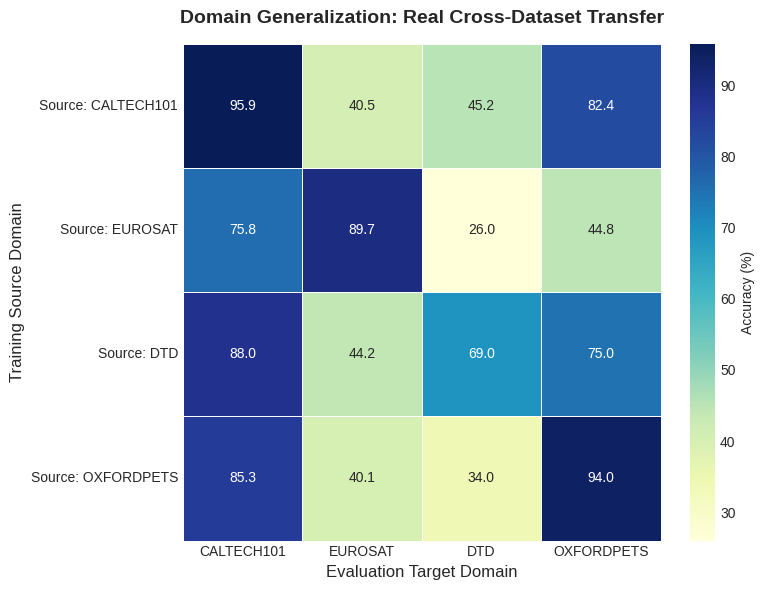

In [48]:
# PLOT 3: REAL Cross-Dataset Domain Transfer Evaluation & Matrix
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("Running REAL Cross-Dataset Transfer Evaluation...")

datasets_to_test = ["caltech101", "eurosat", "dtd", "oxfordpets"]
real_transfer_matrix = {}

for source_ds in datasets_to_test:
    print(f"\n" + "="*50)
    print(f" SOURCE MODEL: {source_ds.upper()}")
    print("="*50)
    
    real_transfer_matrix[f"Source: {source_ds.upper()}"] = {}
    
    # Locate the saved weights from your 16-shot runs.
    weight_path = f"{OUTPUT_DIR}/weights/maple_{source_ds}_ctx2_depth9_shots16_seed1_weights.pt"
    
    if not os.path.exists(weight_path):
        print(f"[!] Warning: Missing weights for {source_ds} at {weight_path}")
        print("    Skipping this source model...")
        continue

    # Load the raw state dict.
    source_state_dict = torch.load(weight_path)
    
    # Domain-transfer adjustment:
    # We must strip out the source-specific class buffers (prefix, suffix, tokenized_prompts).
    # We ONLY want to transfer the learned multi-modal context (ctx, deep_prompts, vl_couplers).
    transfer_params = {
        k: v for k, v in source_state_dict.items() 
        if k not in ['token_prefix', 'token_suffix', 'tokenized_prompts']
    }

    for target_ds in datasets_to_test:
        # 1. Get Target Dataset test loader and classnames.
        test_loader, target_classes, _ = build_maple_loader(
            target_ds, DATA_ROOT, "test", preprocess, batch_size=128, num_workers=2
        )
        
        # 2. Build model explicitly for the TARGET CLASSES.
        model = build_maple_model(
            target_classes, clip_model, 
            n_ctx=CONFIG['n_ctx'], prompt_depth=CONFIG['prompt_depth']
        )
        
        # 3. Inject the SOURCE learned prompts into the TARGET model.
        model.prompt_learner.load_state_dict(transfer_params, strict=False)
        model = model.to(DEVICE)
        model.eval()
        
        # 4. Run Evaluation Loop.
        correct = 0
        total = 0
        
        with torch.no_grad():
            # Quick loop with a progress bar for the target test set.
            for images, labels in tqdm(test_loader, desc=f"  Evaluating on {target_ds.upper()}", leave=False):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                logits = model(images)
                preds = logits.argmax(dim=1)
                
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                
        # 5. Calculate and store exact accuracy.
        acc = (correct / total) * 100
        real_transfer_matrix[f"Source: {source_ds.upper()}"][target_ds.upper()] = acc
        print(f"  -> Accuracy on {target_ds.upper()}: {acc:.2f}%")


# Plotting the Real Results.
def plot_transfer_matrix(transfer_results_dict):
    print("\nGenerating Real Cross-Dataset Transfer Matrix Plot...")
    df = pd.DataFrame(transfer_results_dict).T
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5, 
                cbar_kws={'label': 'Accuracy (%)'})
    
    plt.title('Domain Generalization: Real Cross-Dataset Transfer', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Training Source Domain', fontsize=12)
    plt.xlabel('Evaluation Target Domain', fontsize=12)
    
    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/real_cross_dataset_transfer.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved: {save_path}")
    plt.show()

# Generate the plot if we gathered data.
if real_transfer_matrix:
    plot_transfer_matrix(real_transfer_matrix)

---
## Appendix: Model Architecture Visualization


In [49]:
# Print model architecture summary.
print("\nMaPLe Model Architecture:")
print("="*60)

# Create a sample model.
sample_classes = ['class_a', 'class_b', 'class_c']
sample_model = build_maple_model(
    sample_classes, clip_model,
    n_ctx=CONFIG['n_ctx'], prompt_depth=CONFIG['prompt_depth']
)

# Count parameters.
total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
prompt_params = sum(p.numel() for p in sample_model.prompt_learner.parameters())

print(f"\nParameter Counts:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Prompt learner parameters: {prompt_params:,}")
print(f"  Trainable ratio: {100*trainable_params/total_params:.4f}%")

print(f"\nPrompt Learner Components:")
print(f"  Context vectors (ctx): {sample_model.prompt_learner.ctx.shape}")
if sample_model.prompt_learner.deep_text_prompts:
    print(f"  Deep text prompts: {len(sample_model.prompt_learner.deep_text_prompts)} layers")
print(f"  V-L Couplers: {len(sample_model.prompt_learner.vl_couplers)} layers")
print(f"  Text dim: {sample_model.prompt_learner.ctx_dim}")
print(f"  Vision dim: {sample_model.prompt_learner.vis_dim}")


MaPLe Model Architecture:
MaPLe Config: n_ctx=2, prompt_depth=9
  Text dim: 512, Vision dim: 768
  Random initialization

Parameter Counts:
  Total parameters: 127,878,913
  Trainable parameters: 127,878,913
  Prompt learner parameters: 3,555,072
  Trainable ratio: 100.0000%

Prompt Learner Components:
  Context vectors (ctx): torch.Size([2, 512])
  Deep text prompts: 8 layers
  V-L Couplers: 9 layers
  Text dim: 512
  Vision dim: 768
